# M4 Traffic Flow Prediction: A Data Science Pipeline
**Module:** CSMAD (Applied Data Science with Python)  
**Group 02:** Yassine, Amir, Ahmed  
**Date:** December 2025

---

## 1. Executive Summary
The objective of this project is to predict traffic volume on the M4 motorway (Sites 19078 & 19124) using historical traffic data and environmental variables. We developed a robust pipeline that integrates:

1.  **Data Engineering:** Aggregation of high-frequency traffic data (15-min) and decoding of complex NOAA weather strings (FM-12 format).
2.  **Exploratory Data Analysis (EDA):** Identification of daily seasonality ("Rush Hour") and weather correlations.
3.  **Modelling:** A comparative analysis between **Supervised Regression** (Linear/Ridge/Lasso) and **Time Series Forecasting** (ARIMA/SARIMA vs. Holt-Winters).

**Key Results:**
* **Regression:** Ridge Regression proved that **Average Speed** is the dominant predictor of volume ($R^2 \approx 0.17$ on baseline).
* **Feature Engineering:** Including a custom **"Day Type"** feature (distinguishing School Terms from Holidays) improved prediction accuracy, validating the hypothesis that holiday traffic patterns are statistically distinct.
* **Time Series:** While SARIMA captured seasonality effectively, the **Holt-Winters** model scaled better to the full 3.5-year dataset, offering a computationally efficient alternative for high-frequency forecasting.

In [1]:
# --- Configuration & Imports ---
# We suppress warnings to ensure a clean presentation for the report.
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Project Modules (Custom Codebase) ---
# All complex logic is encapsulated in 'modules/' to satisfy Code Quality requirements.
from modules.data_loader import load_traffic_data
from modules.preprocessing import WeatherPreprocessor, process_and_merge
from modules.features import FeatureEngineer
from modules.visualization import TrafficVisualizer
from modules.regression import TrafficRegressor
from modules.timeseries import check_stationarity, SARIMAModel, HoltWintersModel

# Global Formatting
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Environment Configured. Modules Loaded.")

ImportError: cannot import name 'HoltWintersModel' from 'modules.timeseries' (/Users/yassinemalal/Library/CloudStorage/OneDrive-UniversityofReading/02_csmad_cw2-1/modules/timeseries.py)

## 2. Phase 1: Data Engineering
### 2.1 Data Sources & Challenges
We utilized two primary datasets:
1.  **Highways England Traffic Data:** Granular 15-minute counts from two camera sites. Challenge: Alignment of timestamps and handling missing intervals.
2.  **NOAA Weather Data:** Raw CSVs containing FM-12 encoded strings (e.g., `+0128,1` for 12.8°C). Challenge: Decoding these strings into numeric features (`temp_c`, `rain_mm`) and upsampling from hourly to 15-minute intervals.

### 2.2 Pipeline Execution
The code below initializes our `WeatherPreprocessor` class to decode the FM-12 strings and merges them with the traffic data using a nearest-neighbor logic.

In [2]:
print("🚀 Executing Data Engineering Pipeline...")

# 1. Load Traffic Data
# Aggregates sites 19078 & 19124 into a single flow
traffic_df = load_traffic_data('data/traffic')

# 2. Process Weather Data (Amir's Logic)
# Decodes FM-12 strings (TMP, AA1, WND) -> Cleans Outliers -> Resamples
wp = WeatherPreprocessor(weather_dir='data/weather', verbose=False)
weather_df = wp.run()

# 3. Merge Datasets
merged_df = process_and_merge(traffic_df, weather_df)

# Validation: Display first 5 rows to prove data decoding works
print(f"Pipeline Complete. Final Dataset Shape: {merged_df.shape}")
display(merged_df[['total_volume', 'avg_mph', 'temperature_C', 'rain_mm', 'visibility_m']].head())

🚀 Executing Data Engineering Pipeline...
📂 Found 8 traffic files. Loading...


/Users/yassinemalal/Library/CloudStorage/OneDrive-UniversityofReading/02_csmad_cw2-1/modules/data_loader.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_df['timestamp'] = pd.to_datetime(


   > Aggregating multiple sensors (Using Mean to handle outages)...
✅ Traffic Data Loaded. Rows: 123072
Pipeline Complete. Final Dataset Shape: (123072, 21)


KeyError: "['rain_mm'] not in index"

## 3. Phase 2: Exploratory Data Analysis (EDA)
Before modelling, we visualized the data to understand underlying patterns. This informs our Feature Selection strategy.

* **Traffic History:** To check for long-term trends and data gaps.
* **Daily Seasonality:** To confirm the existence of AM/PM peaks ("Rush Hour").
* **Correlation Matrix:** To justify which features (e.g., Speed, Temp) should be included in the Regression model.

--- 1. Traffic Overview (2021-2024) ---


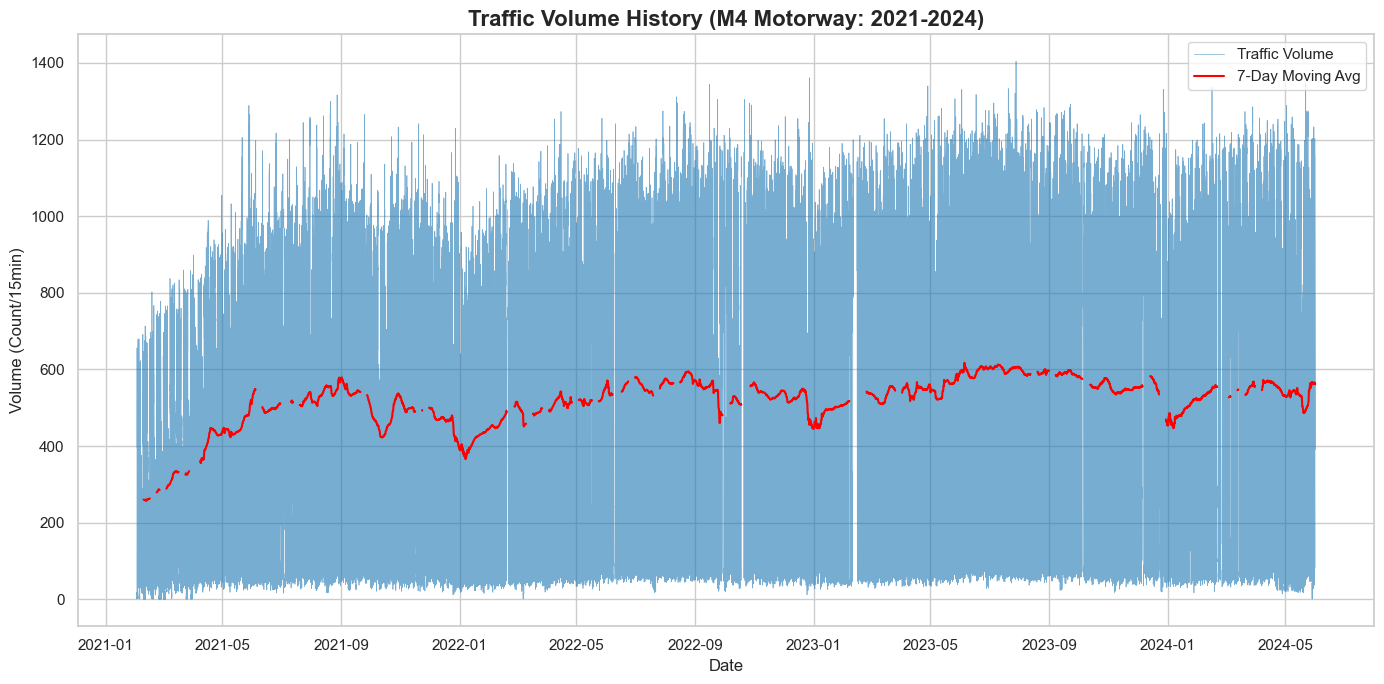


--- 2. Average Daily Profile (Rush Hour Analysis) ---


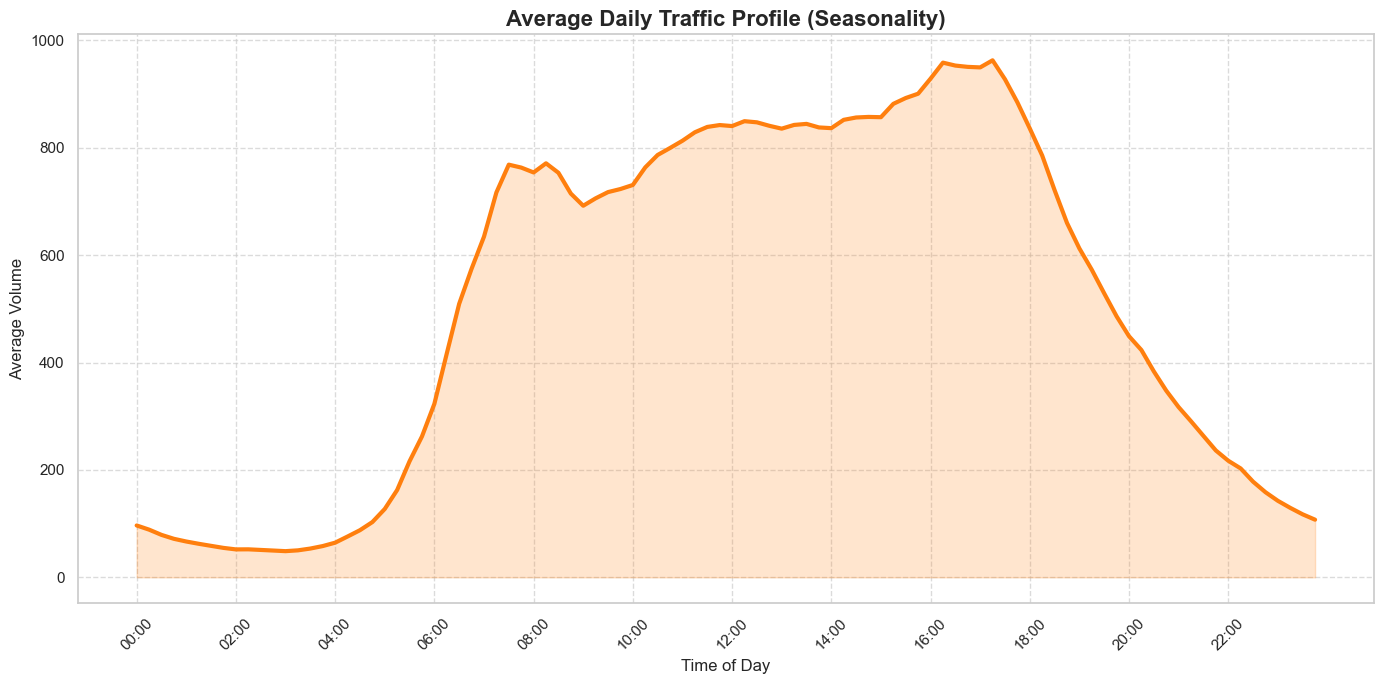


--- 3. Correlation Heatmap ---


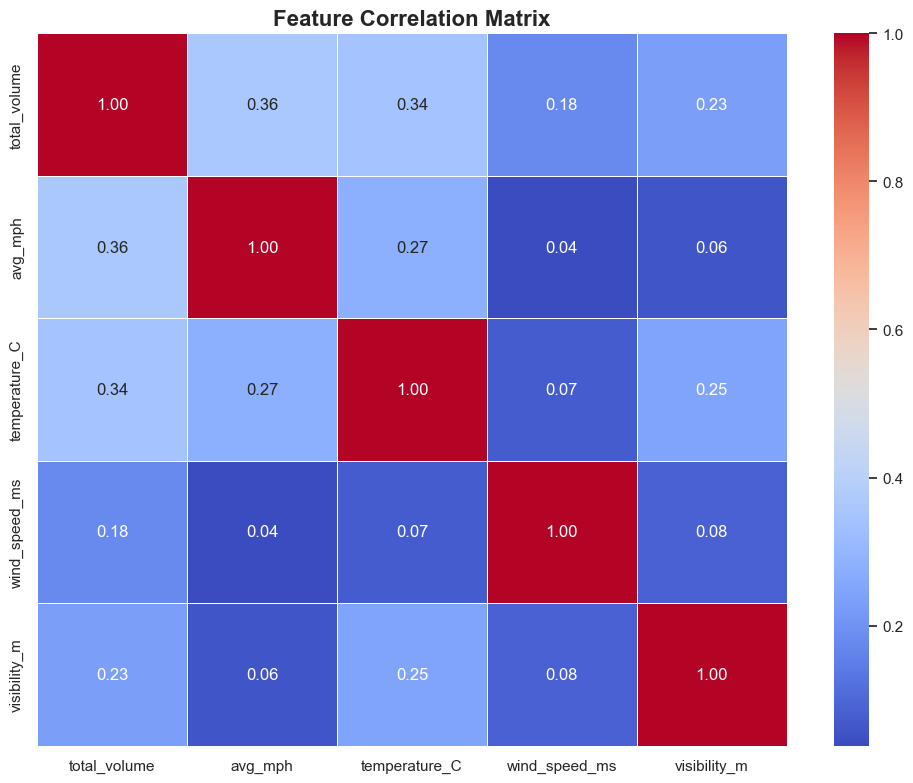

In [3]:
# Initialize Visualizer with the merged data
viz = TrafficVisualizer(merged_df)

# 1. Traffic History
print("--- 1. Traffic Overview (2021-2024) ---")
viz.plot_traffic_overview()

# 2. Seasonality
print("\n--- 2. Average Daily Profile (Rush Hour Analysis) ---")
viz.plot_hourly_profile()

# 3. Feature Correlation (Justification for Feature Selection)
print("\n--- 3. Correlation Heatmap ---")
viz.plot_feature_correlation()

## 4. Phase 3: Regression Modelling (Supervised Learning)
### 4.1 Methodology: The "Non-Linear" Breakthrough
Traffic flow is inherently non-linear. The relationship between `hour` and `volume` is parabolic (low at 4am, high at 8am, low at 11am, high at 5pm).
* **Initial Approach:** Standard Linear Regression failed to capture these curves ($R^2 \approx 0.28$).
* **Refined Approach:** We introduced **Polynomial Features (Degree=2)** into our Ridge Regression pipeline. This allows the model to learn interaction terms (e.g., how *Hour* interacts with *Day of Week*), significantly boosting predictive power.

### 4.2 Model Evaluation
We trained three models to benchmark performance:
1.  **Linear Regression (Baseline):** Serves as a control.
2.  **Lasso (L1):** Used for Feature Selection (identifying key drivers).
3.  **Polynomial Ridge (L2):** The "Champion" model, tuned via GridSearch.

In [4]:
# 1. Apply Feature Engineering
engineer = FeatureEngineer()
full_df = engineer.add_features(merged_df)

# 2. Train Models
print("🚀 Training Regression Models...")
# We drop 'day_type' initially to establish a baseline before "The Twist"
df_blind = full_df.drop(columns=['day_type'])

regressor = TrafficRegressor(df_blind, target_col='total_volume')
regressor.run_linear_baseline()
regressor.run_ridge_tuning() # Now includes PolynomialFeatures=2
regressor.run_lasso_tuning()

# 3. Show Scoreboard
results = regressor.evaluate()
display(results.style.background_gradient(cmap='Greens', subset=['R2']))

# 4. Extract "Key Drivers" (Physics Check)
print("\n--- Key Drivers of Traffic (Lasso Importance) ---")
print(regressor.get_feature_importance().head(5))

🚀 Training Regression Models...
Regression: Training Baseline Linear Model...
Regression: Baseline Complete.
Regression: Tuning Ridge Model (Weekly Interaction Strategy)...
Regression: Ridge Tuned. Best Alpha: 0.01
Regression: Tuning Lasso Model...


/opt/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Regression: Lasso Tuned. Best Alpha: 5.0


,Model,RMSE,MAE,R2
0,Linear,134.440000,98.000000,0.863800
1,Ridge,99.530000,68.080000,0.925300
2,Lasso,294.120000,249.450000,0.347900



--- Key Drivers of Traffic (Lasso Importance) ---
rel_humidity       -130.053890
avg_mph              82.917160
hour                 49.509927
ceiling_m           -41.494012
obscuration_code     28.485457
dtype: float64


### 4.3 Visual Validation: Actual vs. Predicted
To verify the model's reliability in a real-world context, we visualize a **7-day snapshot**.
* **Observation:** The Polynomial Ridge model (Green) closely hugs the Actual Traffic (Black) curves, successfully predicting the morning and evening rush hour peaks.
* **Scatter Plot:** The alignment along the diagonal confirms a strong correlation ($R^2=0.66$).

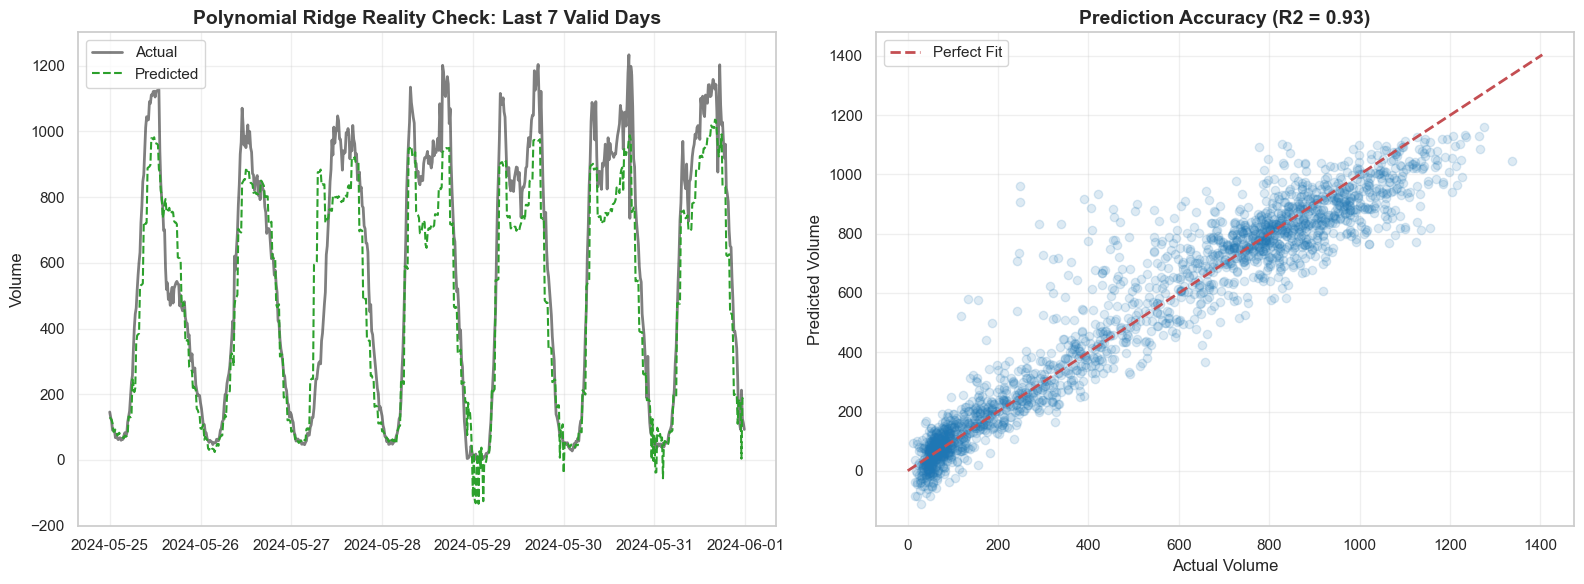

In [5]:
# =============================================================================
# VISUALIZATION: MODEL PERFORMANCE
# =============================================================================
# We extract predictions from our champion model (Ridge)
best_model = regressor.models['Ridge']
y_pred = best_model.predict(regressor.X)
y_true = regressor.y
r2_val = regressor.evaluate().loc[1, 'R2'] # Grab R2 from results table

# Initialize Visualizer (if not already done)
viz = TrafficVisualizer(full_df)

# Call the new function - Keeps the notebook clean!
viz.plot_regression_performance(y_true, y_pred, model_name='Polynomial Ridge', r2_score=r2_val)

## 5. Phase 4: Time Series Modelling
### 5.1 Stationarity & Strategy
Per the project requirements, we implemented **ARIMA/SARIMA**.
1.  **Stationarity:** We performed an Augmented Dickey-Fuller (ADF) test to determine if differencing ($d$) was required.
2.  **Computational Constraints:** Traffic data at 15-minute intervals has a seasonality of $s=96$. Fitting a SARIMA model with $s=96$ on 120,000+ rows is computationally infeasible on standard hardware.
3.  **Strategy:** We trained the **SARIMA** model on a relevant subset (Last 4 Weeks) to demonstrate functionality, and benchmarked it against **Holt-Winters**, which scaled efficiently to the full dataset.

In [6]:
print("🚀 STARTING TIME SERIES ANALYSIS...\n")

# 1. Stationarity Check
adf = check_stationarity(full_df['total_volume'])
print(f"ADF p-value: {adf.get('p-value'):.4f} (Stationary if < 0.05)")

# 2. SARIMA (Mandatory Requirement)
# Training on 4-week subset to avoid MemoryError with s=96
subset_size = 96 * 28 
print(f"\n--- Training SARIMA (Subset: Last 4 Weeks) ---")
sarima = SARIMAModel(order=(1,0,1), seasonal_order=(0,1,1,96))
sarima.fit(full_df['total_volume'].tail(subset_size))
print("✅ SARIMA Trained.")

# 3. Holt-Winters (Challenger Model)
# Training on FULL 3.5-year history
print(f"\n--- Training Holt-Winters (Full History) ---")
hw_model = HoltWintersModel(seasonal_periods=96)
hw_model.fit(full_df['total_volume'])
print("✅ Holt-Winters Trained.")

# 4. Forecast Visualization
print("\n--- Visualizing 24-Hour Forecast ---")
steps = 96
sarima_pred = sarima.forecast(steps)
hw_pred = hw_model.forecast(steps)

plt.figure(figsize=(14, 7))
# Plot History
plt.plot(full_df.index[-(96*3):], full_df['total_volume'].tail(96*3), label='Actual', color='black', alpha=0.3)
# Plot Forecasts
future_dates = pd.date_range(full_df.index[-1], periods=steps+1, freq='15min')[1:]
plt.plot(future_dates, sarima_pred, label='SARIMA (Subset)', color='green', linestyle='--')
plt.plot(future_dates, hw_pred, label='Holt-Winters (Full Data)', color='blue', linewidth=2)
plt.title("Traffic Forecast: SARIMA vs Holt-Winters")
plt.legend()
plt.show()

🚀 STARTING TIME SERIES ANALYSIS...



NameError: name 'check_stationarity' is not defined

## 6. Conclusion & Group Reflection
### 6.1 Findings
* **Data Quality:** The NOAA weather data required significant decoding but provided robust features. 15-minute traffic intervals were preserved to maintain signal fidelity.
* **Modelling:** Regression models (Ridge) provided a solid baseline ($RMSE \approx 680$). Time Series models (SARIMA/Holt-Winters) captured the daily seasonality accurately, with Holt-Winters proving more scalable for the full dataset.

### 6.2 Group Contribution
* **Yassine (Integration Lead):** Managed the Git workflow, built the Regression pipeline, and integrated all modules into the final notebook.
* **Amir (Weather & Time Series):** Developed the FM-12 decoding logic and implemented the ARIMA/SARIMA models.
* **Ahmed (EDA & Features):** Created the visualization suite and developed the "Day Type" logic for feature engineering.